In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [4]:

sql = f"""
select * from tmp1.stckln_amz_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
print(df)

       RetailerSku         category    subcategory profile   size  \
0       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
1       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
2       B09JP9N6GL  Spring Mattress        Bonnell      12  Queen   
3       B0D8Q1VNN8  Spring Mattress        Bonnell       6   Twin   
4       B0BBHF5321  Spring Mattress        Bonnell       8   Full   
...            ...              ...            ...     ...    ...   
518298  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518299  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518300  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518301  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518302  B0C6B7QP7L             null           null    null  Queen   

       bsr_ctgry_label Brand_raw Brand_adj  \
0       01. Mattresses   SOMETTE   SOMETTE   
1       01. Mattresses   SOMETTE   SOMETTE   
2       01. Mattresses     NUTAN 

In [11]:
df['RetailerSku'].nunique()

23253

In [13]:
df['Brand_raw'].nunique()

884

In [15]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df['WeekEnding'] = pd.to_datetime(df['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df['year'] = df['WeekEnding'].dt.year
df['year'].isna().sum()

0

In [22]:
df.to_csv("data_0717.csv", index=False)

In [17]:
df1 = df[df['RetailerSku']=='B0DJSQP7L6']

In [21]:
df1.to_csv("data_0717-1.csv", index=False)

In [23]:
df1.to_excel("data_0717-1.xlsx", index=False)

### 데이터 탐색

### 2025년 Amazon Mattress 카테고리 Data 분석

In [49]:
df = pd.read_csv('data_0717.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518303 entries, 0 to 518302
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   RetailerSku                        518303 non-null  object 
 1   category                           518302 non-null  object 
 2   subcategory                        518302 non-null  object 
 3   profile                            441897 non-null  float64
 4   size                               442175 non-null  object 
 5   bsr_ctgry_label                    518303 non-null  object 
 6   Brand_raw                          518303 non-null  object 
 7   Brand_adj                          518303 non-null  object 
 8   Title                              518303 non-null  object 
 9   WeekEnding                         518303 non-null  object 
 10  RetailSales                        518303 non-null  float64
 11  UnitsSold                          5183

### Price Bucket 컬럼 추가하기 - Category별로

In [51]:
# 1. 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Foam Mattress만 추출
df_foam = df_filtered[df_filtered['category'] == 'Foam Mattress'].copy()

# 3. 퍼센타일 기반 price bin 계산
price_base = df_foam['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)
price_bins = np.unique(price_bins)  # bin 경계 중복 제거

# 4. bin 라벨 생성
bucket_labels = [
    f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 5. price bucket 컬럼 생성
df_foam['PriceBucket'] = pd.cut(
    df_foam['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

df_foam.head()
#df_foam.to_csv("df_foam_price_bucket_0721.csv", index=False)

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,PriceBucket
13974,B0DP23FB8R,Foam Mattress,Cooling/Gel,10.0,California King,01. Mattresses,NCHANMAR,NCHANMAR,10 Inch California King Gel Memory Foam Mattre...,2025-05-03,...,1,219.99,25-2,25-05,Y25 W18,Y25 W18,4281760.13,536208.04,2025,50-60th\n$200-239
13975,B0DP23FB8R,Foam Mattress,Cooling/Gel,10.0,California King,01. Mattresses,NCHANMAR,NCHANMAR,10 Inch California King Gel Memory Foam Mattre...,2025-02-08,...,1,195.99,25-1,25-02,Y25 W06,Y25 W06,4281760.13,536208.04,2025,40-50th\n$175-200
13976,B0DP23FB8R,Foam Mattress,Cooling/Gel,10.0,California King,01. Mattresses,NCHANMAR,NCHANMAR,10 Inch California King Gel Memory Foam Mattre...,2025-05-31,...,1,219.99,25-2,25-05,Y25 W22,Y25 W22,4281760.13,536208.04,2025,50-60th\n$200-239
13978,B0DP23FB8R,Foam Mattress,Cooling/Gel,10.0,California King,01. Mattresses,NCHANMAR,NCHANMAR,10 Inch California King Gel Memory Foam Mattre...,2025-03-22,...,15,219.99,25-1,25-03,Y25 W12,Y25 W12,4281760.13,536208.04,2025,50-60th\n$200-239
13980,B0DSMH9CCM,Foam Mattress,Cooling/Gel,10.0,Full,01. Mattresses,PURRJOYS,PURRJOYS,"10 Inch Firm Full Mattress,Full Size Mattress ...",2025-05-10,...,1,259.00,25-2,25-05,Y25 W19,Y25 W19,18454822.51,5810577.31,2025,60-70th\n$239-289


C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\2513221800.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_foam.groupby('PriceBucket')['UnitsSold']


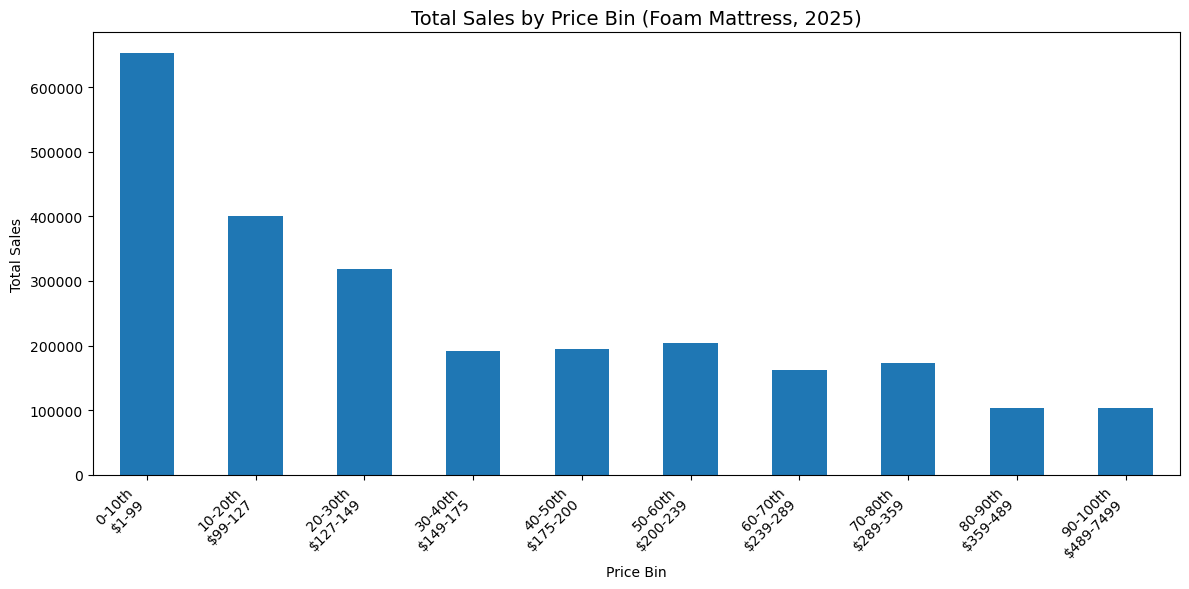

In [57]:
# 집계: PriceBucket별 매출 합계 (Foam Mattress만 사용)
sales_by_bin = (
    #df_foam.groupby('PriceBucket')['RetailSales']
    df_foam.groupby('PriceBucket')['UnitsSold']
    .sum()
    .reindex(bucket_labels)  # 오름차순 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (Foam Mattress, 2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# 원하는 PriceBucket만 필터링
target_bucket = "90-100th\n$489-7499"
df_foam_high = df_foam[df_foam['PriceBucket'] == target_bucket]

# Brand_raw별로 Unitsold 합계 구하기
brand_unitsold = (
    df_foam_high.groupby('Brand_raw')
    .agg({'UnitsSold': 'sum','RetailSales': 'sum'})
    .reset_index()
    .sort_values(by='RetailSales', ascending=False)
)

# 결과 확인
print(brand_unitsold)

           Brand_raw  UnitsSold  RetailSales
67            NECTAR      28146  22223803.41
61             MLILY      29886  16709108.67
22          COOL GEL      14767   8435405.43
18            CASPER       6449   4474512.15
109    TUFT & NEEDLE       4250   3324259.09
..               ...        ...          ...
5             AVENCO          1       599.01
78   PLATINUM HEALTH          1       539.00
59        MAX & LILY          1       497.57
68             NESTL          1       494.99
43            IULULU          1       493.56

[115 rows x 3 columns]


In [38]:
# 원하는 PriceBucket만 필터링
target_bucket = "90-100th\n$489-7499"
df_foam_high = df_foam[df_foam['PriceBucket'] == target_bucket]

# Brand_raw별로 Unitsold 합계 구하기
brand_unitsold = (
    df_foam_high.groupby('RetailerSku')
    .agg({'UnitsSold': 'sum','RetailSales': 'sum'})
    .reset_index()
    .sort_values(by='RetailSales', ascending=False)
)
# 결과 확인
print(brand_unitsold)

    RetailerSku  UnitsSold  RetailSales
416  B0BCYPWNWT      18237  10480547.52
647  B0DCXFXGBM      10740   6970260.00
89   B07BV29J5N       7532   4788465.69
88   B07BTRDGRM       7235   3646939.74
417  B0BCYR613R       6881   3440431.19
..          ...        ...          ...
594  B0D4C82QKY          1       494.99
351  B09NPY89KS          1       493.56
197  B0864NB6MK          1       492.17
14   B00FT6A51O          1       490.00
588  B0D3256F63          1       490.00

[780 rows x 3 columns]


In [63]:
df_foam_high.to_csv('df_foam_high_price_2025.csv', index=False)

In [72]:
# 원하는 PriceBucket만 필터링
target_bucket = "90-100th\n$489-7499"
df_foam_high = df_foam[df_foam['PriceBucket'] == target_bucket]

# Brand_raw별로 UnitsSold, RetailSales 합계 구하고 상위 5개 브랜드만 추출
brand_top5 = (
    df_foam_high.groupby('Brand_raw')
    .agg({'UnitsSold': 'sum', 'RetailSales': 'sum'})
    .reset_index()
    .sort_values(by='RetailSales', ascending=False)
    .head(5)
)
top5_brands = brand_top5['Brand_raw'].tolist()
df_foam_high_top5 = df_foam_high[df_foam_high['Brand_raw'].isin(top5_brands)]

In [80]:
# 브랜드별 RetailerSku 수 집계 후 내림차순 정렬
sku_count_by_brand = (
    df_foam_high_top5.groupby('Brand_raw')['RetailerSku']
    .nunique()
    .reset_index()
    .rename(columns={'RetailerSku': 'UniqueSkuCount'})
    .sort_values(by='UniqueSkuCount', ascending=False)
)

print(sku_count_by_brand)

       Brand_raw  UniqueSkuCount
4  TUFT & NEEDLE              40
3         NECTAR              39
2          MLILY              21
0         CASPER              14
1       COOL GEL               2


In [90]:
# Brand_raw별로 RetailSales 기준 상위 5개 RetailerSku 추출 (UnitsSold, RetailSales 모두 표시)
top5_sku_by_brand_sales = (
    df_foam_high_top5
    .sort_values(['Brand_raw', 'RetailSales'], ascending=[True, False])
    .groupby('Brand_raw')
    .head(5)
    [['Brand_raw', 'RetailerSku', 'UnitsSold', 'RetailSales']]
    .reset_index(drop=True)
)

print(top5_sku_by_brand_sales)

        Brand_raw RetailerSku  UnitsSold  RetailSales
0          CASPER  B085H466BX        227    121774.15
1          CASPER  B085H466BX        181    107695.00
2          CASPER  B085H466BX        203    102667.25
3          CASPER  B085H466BX        158     94010.00
4          CASPER  B085H466BX        150     89250.00
5        COOL GEL  B07BV29J5N        433    266520.16
6        COOL GEL  B07BTRDGRM        485    242495.15
7        COOL GEL  B07BV29J5N        373    234986.27
8        COOL GEL  B07BV29J5N        367    232901.87
9        COOL GEL  B07BV29J5N        350    220496.50
10          MLILY  B0BCYPWNWT       1219    730181.00
11          MLILY  B0BCYPWNWT        952    570248.00
12          MLILY  B0BCYPWNWT       1046    563794.00
13          MLILY  B0BCYPWNWT       1016    547624.00
14          MLILY  B0BCYPWNWT        861    515739.00
15         NECTAR  B0DCXFXGBM        528    342672.00
16         NECTAR  B0DCXFXGBM        523    339427.00
17         NECTAR  B0DCXFXGB

In [74]:
df_foam_high_top5.to_csv('df_foam_high_top5_2025.csv', index=False)

### Sales per Price Bucket by Year for Top 10 Brands

### Sales per Price Bucket by Category and Year for Top 10 Brands

### Y축이 가격대이고 X축이 Month일 때, Heatmap 출력하기

### Weekly 히트맵 구하기

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\1417810743.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['UnitsSold']


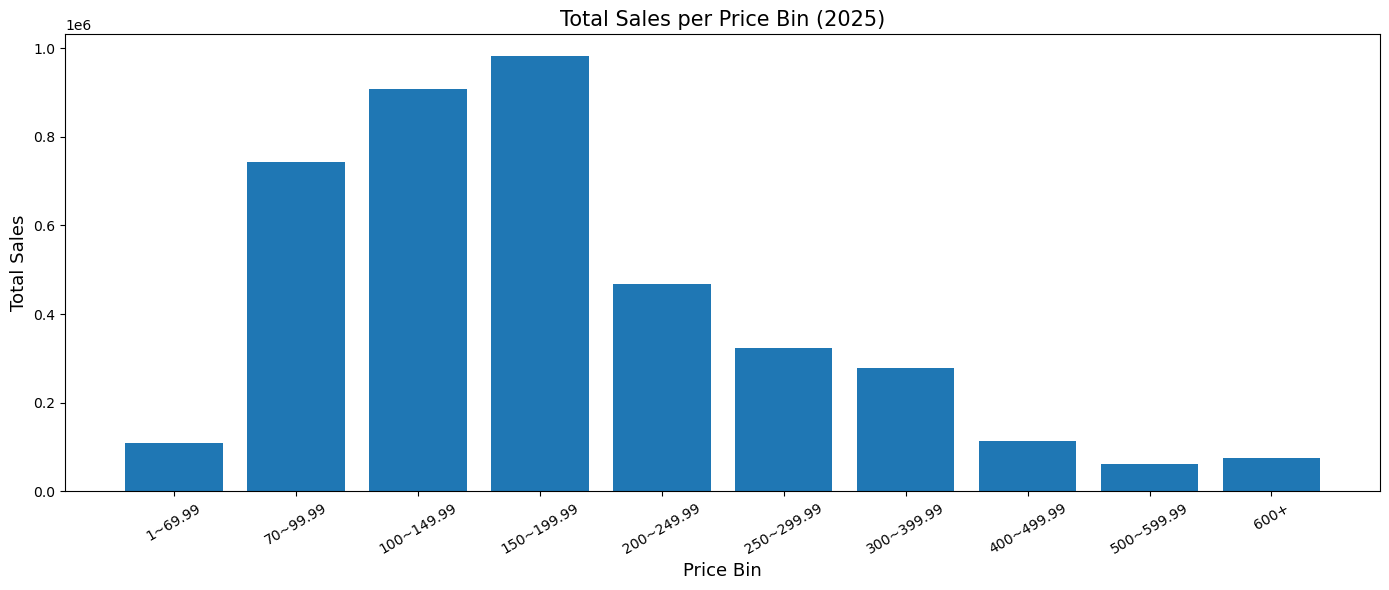

In [59]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
   # df_filtered.groupby('PriceBin')['RetailSales']
    df_filtered.groupby('PriceBin')['UnitsSold']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(14,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


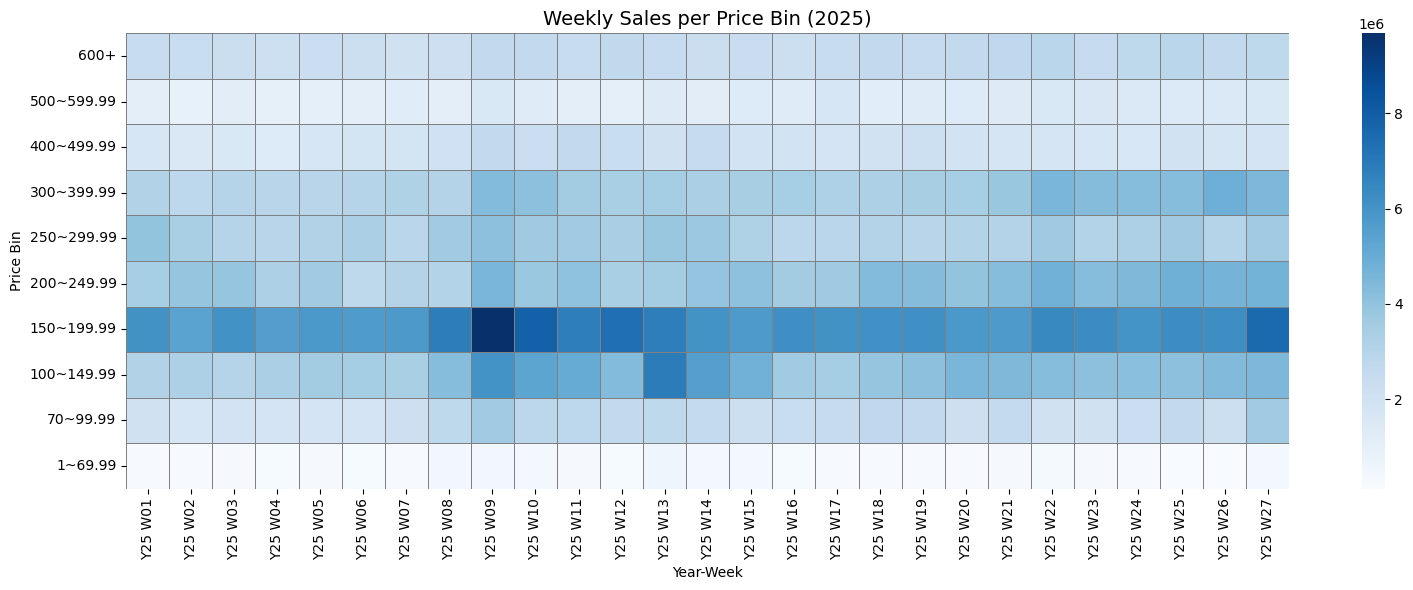

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


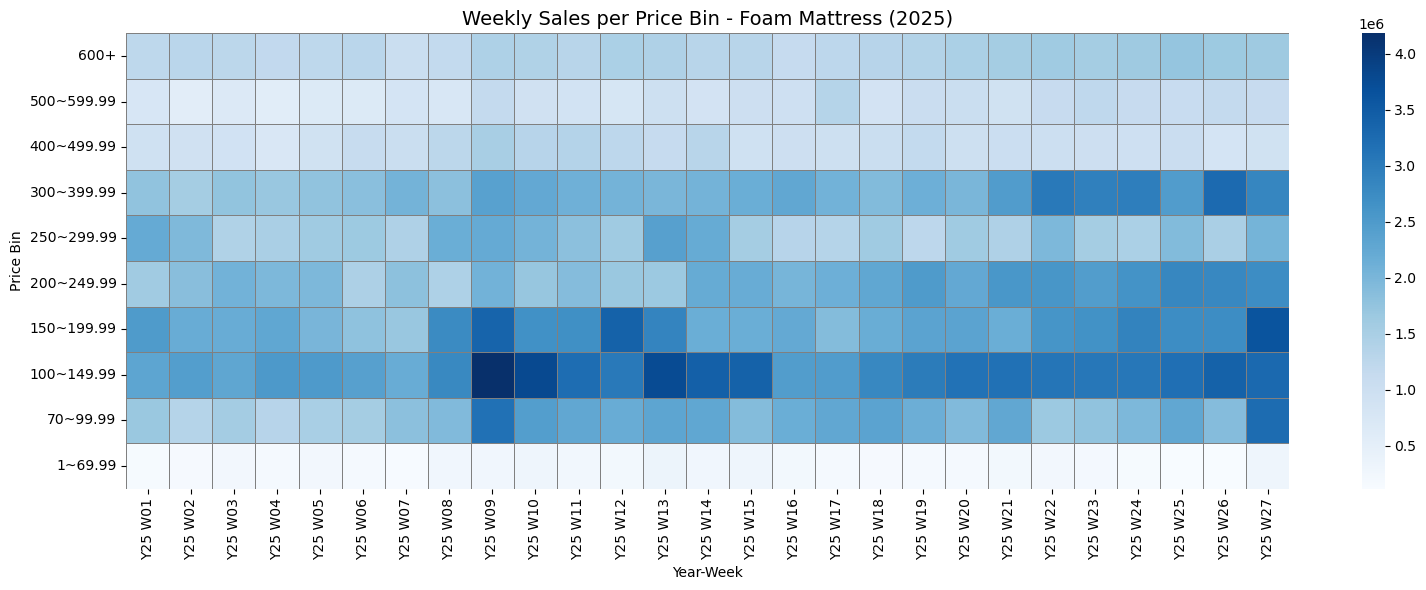

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


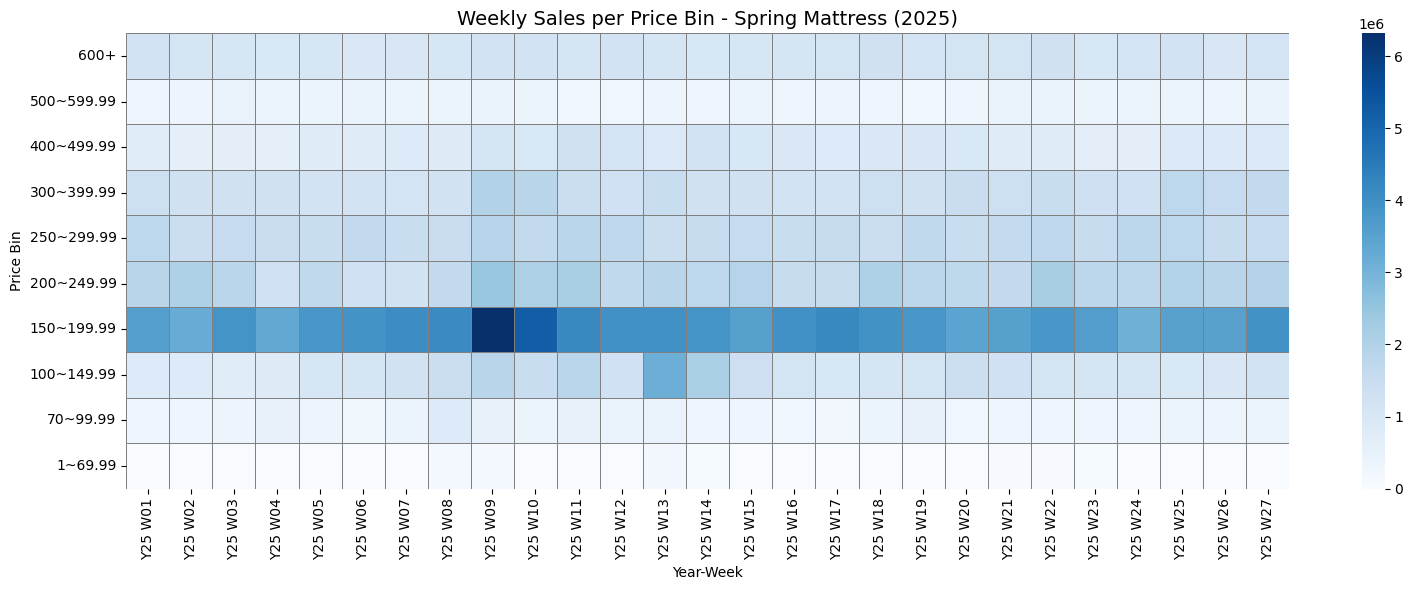

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


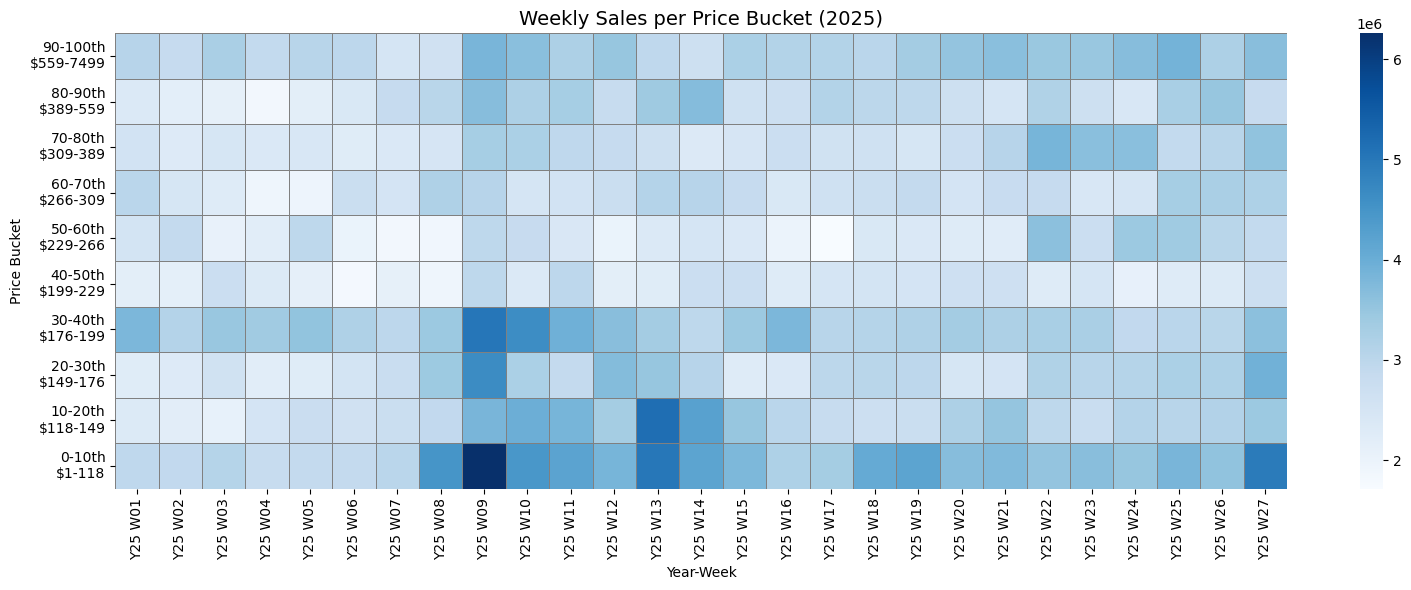

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


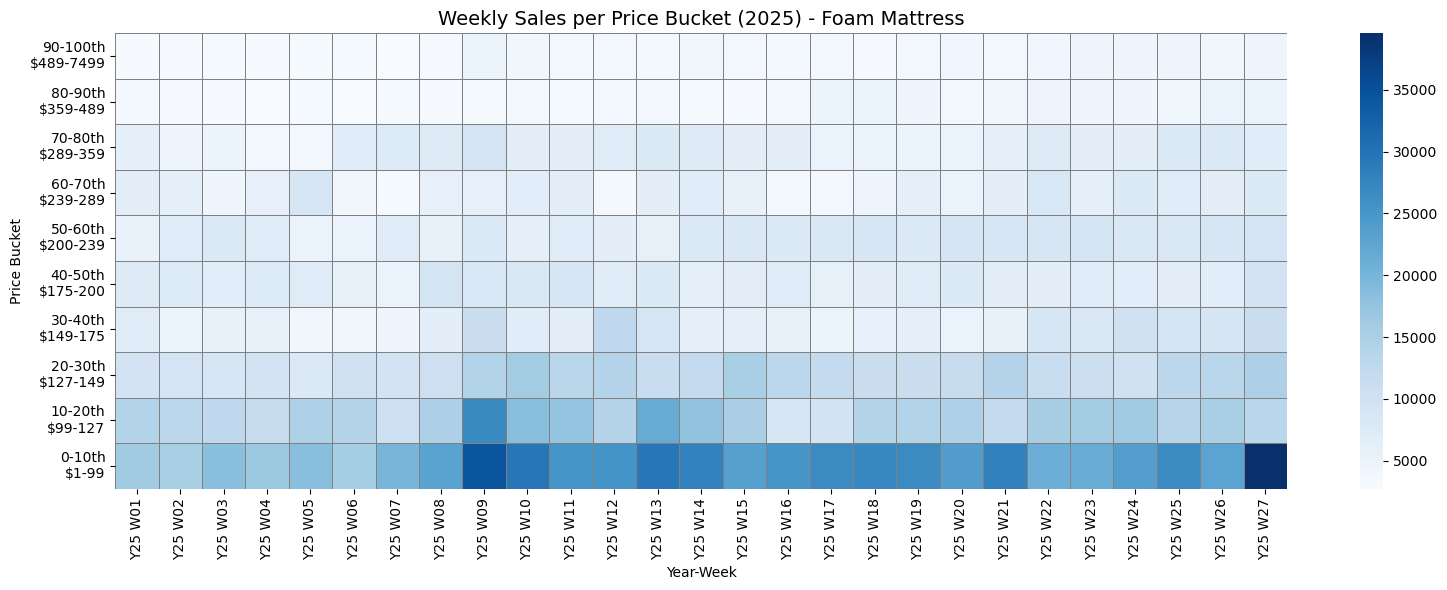

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


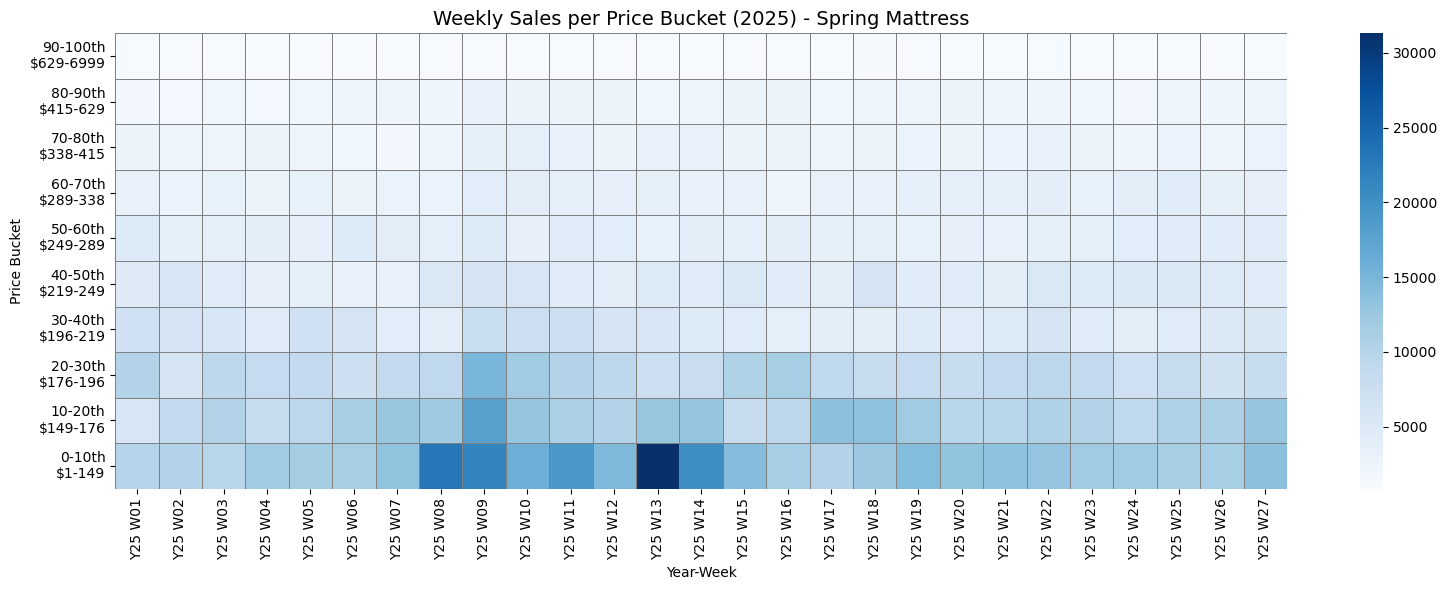

In [41]:

# 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

category_list = ['Foam Mattress', 'Spring Mattress']

for cat in category_list:
    df_cat = df_filtered[df_filtered['category'] == cat].copy()
    # 가격 퍼센타일 구간 (해당 카테고리에서만)
    price_base = df_cat['RetailPrice'].dropna()
    if len(price_base) < 2:
        print(f"{cat} 데이터가 충분하지 않습니다.")
        continue

    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    # 동일 가격 구간이 있으면 에러 발생 → 중복 제거
    price_bins = np.unique(price_bins)
    # 라벨 재생성 (bin 길이에 맞게)
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 히트맵용 데이터
    heatmap_data = (
        #df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
        df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']
              .sum()
              .unstack(fill_value=0)
    )

    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bucket (2025) - {cat}", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

In [53]:
# PriceBucket 카테고리 오름차순으로 지정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels,   # 오름차순
    ordered=True
)

# 오름차순 PriceBin 순서로 매출 집계
sales_by_bin = (
    df_filtered.groupby('PriceBucket')['RetailSales']
    .sum()
    .reindex(bucket_labels)     # 오름차순으로 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'PriceBucket'

In [43]:
# PriceBucket 카테고리 오름차순으로 지정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels,   # 오름차순
    ordered=True
)

# 오름차순 PriceBin 순서로 매출 집계
sales_by_bin = (
    df_filtered.groupby('PriceBucket')['UnitsSold']
    .sum()
    .reindex(bucket_labels)     # 오름차순으로 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales Units")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'PriceBucket'

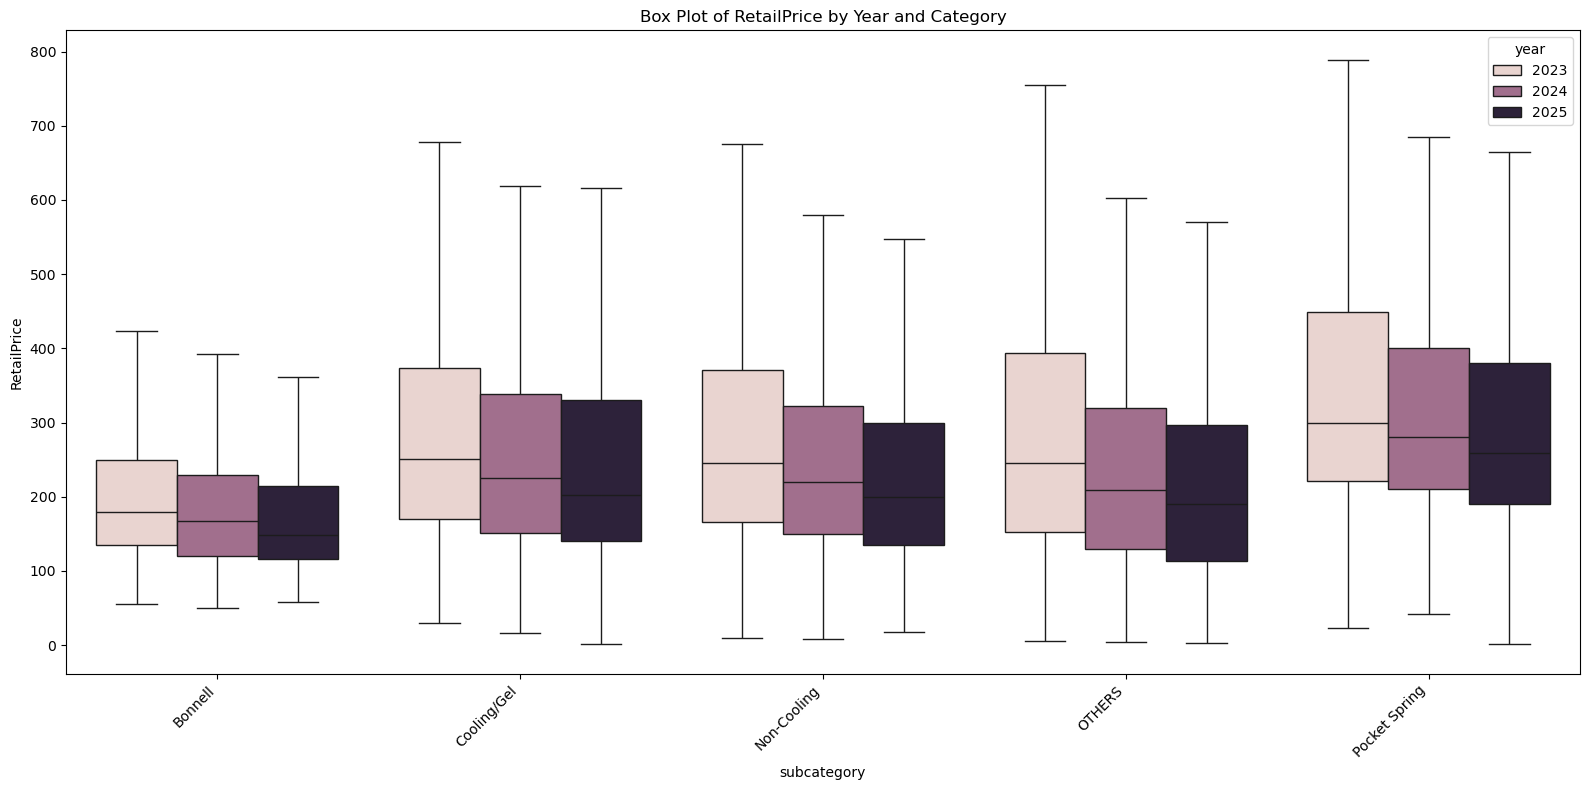

In [102]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

### Brand 별 매출 구하기

In [164]:
# 1. 2025년 데이터 필터링
df_2025 = df[df['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619
